## <Data Science Salaries 2024>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)

In [2]:
df=pd.read_csv("DS Salaries 2024.csv")

print(df)

       work_year experience_level employment_type  \
0           2021               MI              FT   
1           2021               MI              FT   
2           2020               MI              FT   
3           2021               MI              FT   
4           2022               SE              FT   
...          ...              ...             ...   
14833       2022               MI              FT   
14834       2020               EX              FT   
14835       2021               EN              FT   
14836       2022               EN              FT   
14837       2020               EN              PT   

                             job_title    salary salary_currency  \
0                       Data Scientist  30400000             CLP   
1                      BI Data Analyst  11000000             HUF   
2                       Data Scientist  11000000             HUF   
3                          ML Engineer   8500000             JPY   
4       Lead Machine Le

#### [Data Pre-Processing]

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14838 entries, 0 to 14837
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           14838 non-null  int64 
 1   experience_level    14838 non-null  object
 2   employment_type     14838 non-null  object
 3   job_title           14838 non-null  object
 4   salary              14838 non-null  int64 
 5   salary_currency     14838 non-null  object
 6   salary_in_usd       14838 non-null  int64 
 7   employee_residence  14838 non-null  object
 8   remote_ratio        14838 non-null  int64 
 9   company_location    14838 non-null  object
 10  company_size        14838 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.2+ MB
None


In [4]:
# Missing Value

print(df.isna().sum())

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


#### [Exploratory Data Analysis, EDA]

In [5]:
print(df.describe())

          work_year        salary  salary_in_usd  remote_ratio
count  14838.000000  1.483800e+04   14838.000000  14838.000000
mean    2023.138900  1.650227e+05  149874.718763     32.760480
std        0.700799  3.562354e+05   69009.181349     46.488278
min     2020.000000  1.400000e+04   15000.000000      0.000000
25%     2023.000000  1.021000e+05  102000.000000      0.000000
50%     2023.000000  1.422000e+05  141300.000000      0.000000
75%     2024.000000  1.875000e+05  185900.000000    100.000000
max     2024.000000  3.040000e+07  800000.000000    100.000000


In [6]:
print(df["work_year"].value_counts())

work_year
2023    8519
2024    4374
2022    1652
2021     218
2020      75
Name: count, dtype: int64


In [7]:
print(df["experience_level"].value_counts())

experience_level
SE    9696
MI    3553
EN    1148
EX     441
Name: count, dtype: int64


In [8]:
print(df["employment_type"].value_counts())

employment_type
FT    14772
PT       27
CT       26
FL       13
Name: count, dtype: int64


In [9]:
print(df["job_title"].value_counts())

job_title
Data Engineer                      3162
Data Scientist                     3015
Data Analyst                       2189
Machine Learning Engineer          1542
Research Scientist                  475
                                   ... 
Deep Learning Researcher              1
Big Data Developer                    1
AWS Data Architect                    1
Staff Machine Learning Engineer       1
CRM Data Analyst                      1
Name: count, Length: 153, dtype: int64


In [10]:
minor_job_titles=df["job_title"].value_counts()[df["job_title"].value_counts()<15].index
print(minor_job_titles)

Index(['Applied Machine Learning Scientist', 'Cloud Database Engineer',
       'Applied Data Scientist', 'Deep Learning Engineer', 'Big Data Engineer',
       'Insight Analyst', 'Head of Data Science',
       'Data Visualization Specialist', 'Lead Data Scientist',
       'Data Operations Specialist', 'Principal Data Scientist',
       'Data Management Specialist', 'Data Science Director',
       'Robotics Software Engineer', 'Data Analytics Consultant',
       'Machine Learning Developer', 'AI Programmer', 'AI Research Engineer',
       'Head of Machine Learning', 'Machine Learning Operations Engineer',
       'Lead Data Engineer', 'Product Data Analyst', 'Lead Data Analyst',
       'Data Analytics Specialist', 'Data Product Owner', 'Robotics Engineer',
       'Data Analytics Engineer', 'Data Quality Engineer',
       'Machine Learning Research Engineer',
       'Computer Vision Software Engineer', 'Lead Machine Learning Engineer',
       'Business Intelligence Lead', 'Financial Data A

In [11]:
for index, row in df.iterrows():
    if row["job_title"] in minor_job_titles:
        df.drop(index, axis=0, inplace=True)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 14437 entries, 0 to 14837
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           14437 non-null  int64 
 1   experience_level    14437 non-null  object
 2   employment_type     14437 non-null  object
 3   job_title           14437 non-null  object
 4   salary              14437 non-null  int64 
 5   salary_currency     14437 non-null  object
 6   salary_in_usd       14437 non-null  int64 
 7   employee_residence  14437 non-null  object
 8   remote_ratio        14437 non-null  int64 
 9   company_location    14437 non-null  object
 10  company_size        14437 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.3+ MB
None


In [12]:
print(df["job_title"].value_counts().head(10))

job_title
Data Engineer                     3162
Data Scientist                    3015
Data Analyst                      2189
Machine Learning Engineer         1542
Research Scientist                 475
Analytics Engineer                 403
Applied Scientist                  383
Data Architect                     369
Research Engineer                  276
Business Intelligence Engineer     230
Name: count, dtype: int64


In [13]:
print(df["employee_residence"].value_counts())

employee_residence
US    12712
GB      610
CA      371
ES      124
DE       73
      ...  
CN        1
MY        1
QA        1
IL        1
ID        1
Name: count, Length: 79, dtype: int64


In [14]:
print(df["remote_ratio"].value_counts())

remote_ratio
0      9674
100    4574
50      189
Name: count, dtype: int64


In [15]:
print(df["company_location"].value_counts())

company_location
US    12748
GB      616
CA      371
ES      121
DE       80
      ...  
IR        1
BA        1
QA        1
HK        1
EC        1
Name: count, Length: 70, dtype: int64


In [16]:
print(df["company_size"].value_counts())

company_size
M    13426
L      867
S      144
Name: count, dtype: int64


In [17]:
df.drop(["salary", "salary_currency"], axis=1, inplace=True)

print(df)

       work_year experience_level employment_type  \
0           2021               MI              FT   
1           2021               MI              FT   
2           2020               MI              FT   
3           2021               MI              FT   
5           2021               MI              FT   
...          ...              ...             ...   
14831       2022               EN              FT   
14832       2024               EN              PT   
14833       2022               MI              FT   
14836       2022               EN              FT   
14837       2020               EN              PT   

                             job_title  salary_in_usd employee_residence  \
0                       Data Scientist          40038                 CL   
1                      BI Data Analyst          36259                 HU   
2                       Data Scientist          35735                 HU   
3                          ML Engineer          77364      

In [18]:
df.groupby("work_year")["salary_in_usd"].mean()

work_year
2020    100579.758621
2021     95139.706897
2022    135172.538365
2023    154488.804715
2024    152071.254110
Name: salary_in_usd, dtype: float64

In [19]:
df.groupby("experience_level")["salary_in_usd"].mean()

experience_level
EN     93186.289694
EX    192927.427873
MI    126562.504676
SE    164081.096547
Name: salary_in_usd, dtype: float64

In [20]:
df.groupby("employment_type")["salary_in_usd"].mean()

employment_type
CT     96814.000000
FL     55285.714286
FT    150950.724203
PT     72813.760000
Name: salary_in_usd, dtype: float64

In [21]:
df.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False).head(10)

job_title
AI Architect                    255142.357143
Director of Data Science        218775.333333
Head of Data                    210013.714286
Data Infrastructure Engineer    207332.812500
Prompt Engineer                 205093.588235
Data Analytics Lead             198241.944444
ML Engineer                     197496.711656
Research Scientist              194217.117895
Machine Learning Scientist      192214.056452
Data Science Manager            191612.114035
Name: salary_in_usd, dtype: float64

In [22]:
df.groupby("job_title")["salary_in_usd"].min().sort_values(ascending=False).head(10)

job_title
Data Infrastructure Engineer     135920
Decision Scientist               123040
AI Architect                      99750
Business Intelligence Manager     82500
Data Product Manager              75000
Business Intelligence             70000
Data Integration Engineer         70000
Data Science Practitioner         68400
Data Strategist                   65000
Data Science Lead                 61520
Name: salary_in_usd, dtype: int64

#### [Visualization]

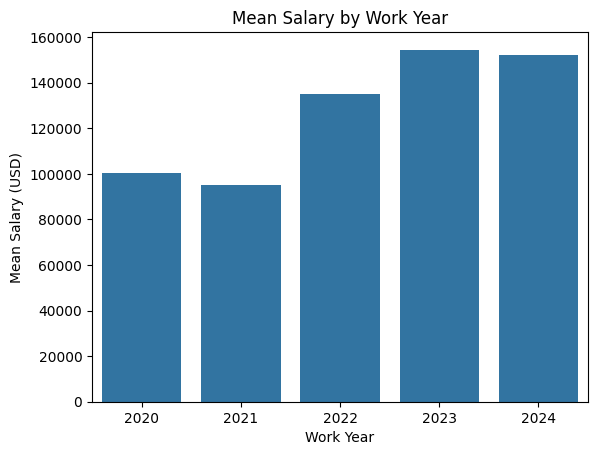

In [23]:
sns.barplot(x=df.groupby("work_year")["salary_in_usd"].mean().index, y=df.groupby("work_year")["salary_in_usd"].mean().values)
plt.xlabel("Work Year")
plt.ylabel("Mean Salary (USD)")
plt.title("Mean Salary by Work Year")

plt.show()

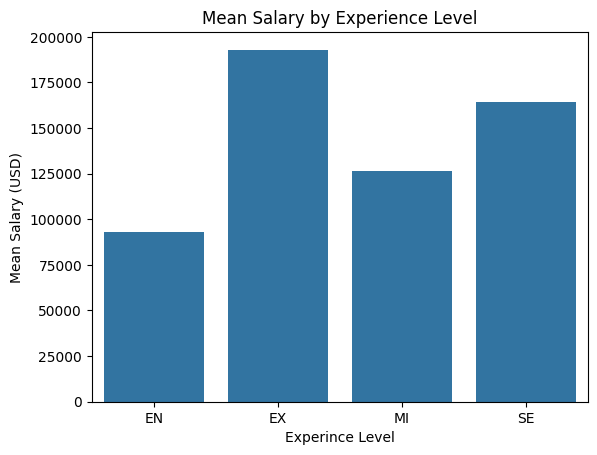

In [24]:
sns.barplot(x=df.groupby("experience_level")["salary_in_usd"].mean().index, y=df.groupby("experience_level")["salary_in_usd"].mean().values)
plt.xlabel("Experince Level")
plt.ylabel("Mean Salary (USD)")
plt.title("Mean Salary by Experience Level")

plt.show()

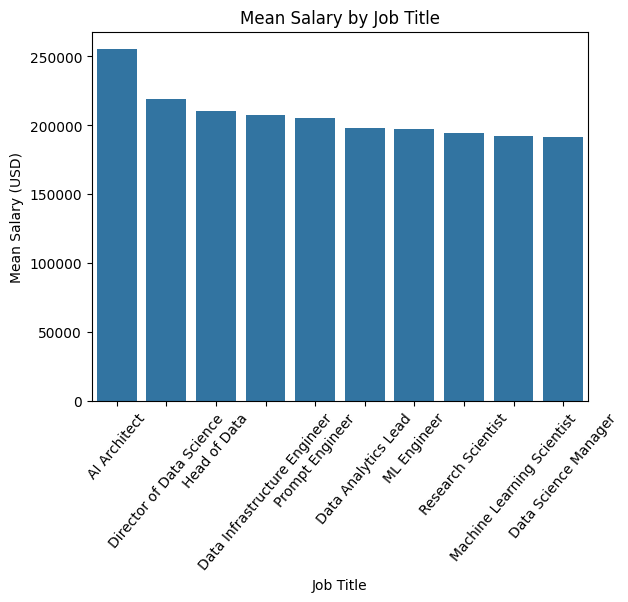

In [25]:
sns.barplot(x=df.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False).head(10).index, y=df.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False).head(10).values)
plt.xlabel("Job Title")
plt.ylabel("Mean Salary (USD)")
plt.title("Mean Salary by Job Title")
plt.xticks(rotation=50)

plt.show()

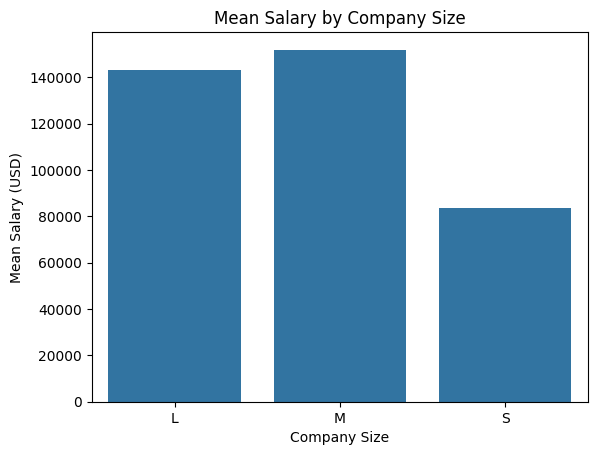

In [26]:
sns.barplot(x=df.groupby("company_size")["salary_in_usd"].mean().index, y=df.groupby("company_size")["salary_in_usd"].mean().values)
plt.xlabel("Company Size")
plt.ylabel("Mean Salary (USD)")
plt.title("Mean Salary by Company Size")

plt.show()

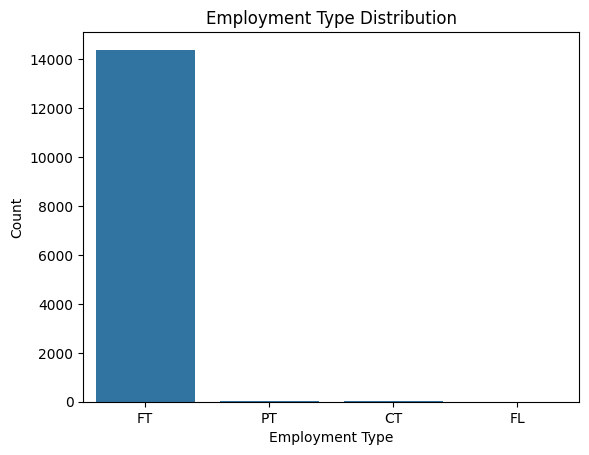

In [27]:
sns.barplot(x=df["employment_type"].value_counts().index, y=df["employment_type"].value_counts())
plt.xlabel("Employment Type")
plt.ylabel("Count")
plt.title("Employment Type Distribution")

plt.show()

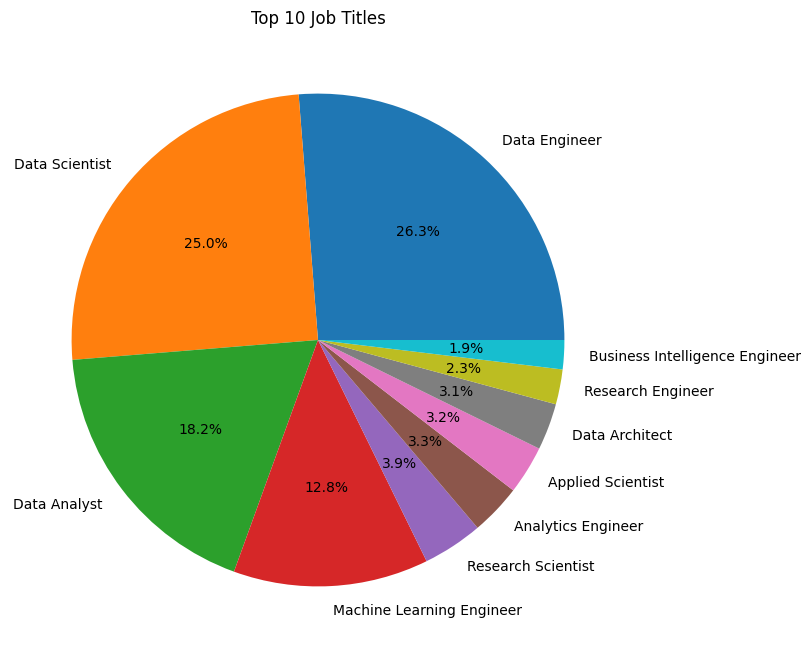

In [28]:
plt.figure(figsize=(8, 8))
plt.pie(df["job_title"].value_counts().head(10), labels=df["job_title"].value_counts().head(10).index, autopct="%1.1f%%")
plt.title("Top 10 Job Titles")

plt.show()

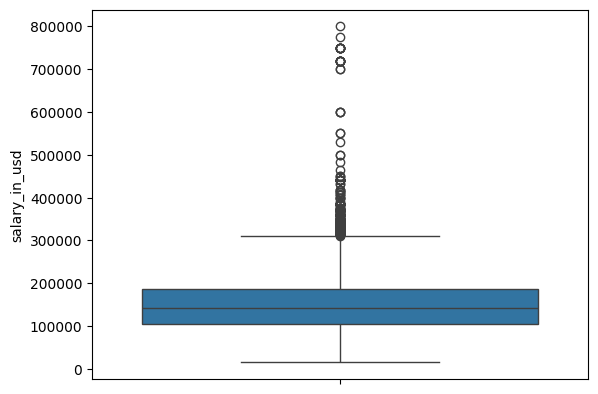

In [29]:
sns.boxplot(data=df["salary_in_usd"])

plt.show()

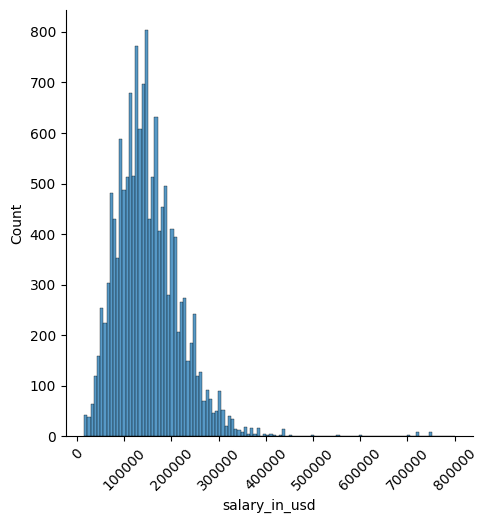

In [30]:
sns.displot(data=df["salary_in_usd"])
plt.xticks(rotation=45)

plt.show()

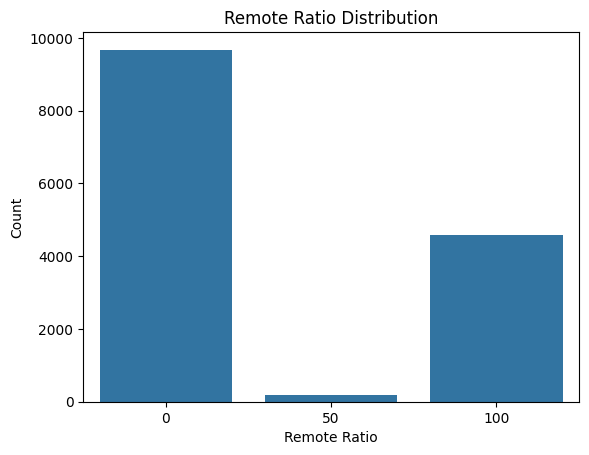

In [31]:
sns.barplot(x=df["remote_ratio"].value_counts().index, y=df["remote_ratio"].value_counts())
plt.xlabel("Remote Ratio")
plt.ylabel("Count")
plt.title("Remote Ratio Distribution")

plt.show()

In [32]:
# Radar Chart

categories=["No Remote Work", "Partially Remote", "Fully Remote"]

fig=go.Figure()

fig.add_trace(go.Scatterpolar(
    r=df[df["work_year"]==2020]["remote_ratio"].value_counts().sort_index() / len(df[df["work_year"]==2020]),
    theta=categories,
    fill="toself",
    name="2020"
))

fig.add_trace(go.Scatterpolar(
    r=df[df["work_year"]==2021]["remote_ratio"].value_counts().sort_index() / len(df[df["work_year"]==2021]),
    theta=categories,
    fill="toself",
    name="2021"
))

fig.add_trace(go.Scatterpolar(
    r=df[df["work_year"]==2022]["remote_ratio"].value_counts().sort_index() / len(df[df["work_year"]==2022]),
    theta=categories,
    fill="toself",
    name="2022"
))

fig.add_trace(go.Scatterpolar(
    r=df[df["work_year"]==2023]["remote_ratio"].value_counts().sort_index() / len(df[df["work_year"]==2023]),
    theta=categories,
    fill="toself",
    name="2023"
))

fig.add_trace(go.Scatterpolar(
    r=df[df["work_year"]==2024]["remote_ratio"].value_counts().sort_index() / len(df[df["work_year"]==2024]),
    theta=categories,
    fill="toself",
    name="2024"
))

fig.update_layout(
    autosize=False,
    width=900,
    height=700
)

fig.show()

#### [Model Training & Prediction]

In [33]:
data=df.drop(["employee_residence", "company_location"], axis=1)

print(data)

       work_year experience_level employment_type  \
0           2021               MI              FT   
1           2021               MI              FT   
2           2020               MI              FT   
3           2021               MI              FT   
5           2021               MI              FT   
...          ...              ...             ...   
14831       2022               EN              FT   
14832       2024               EN              PT   
14833       2022               MI              FT   
14836       2022               EN              FT   
14837       2020               EN              PT   

                             job_title  salary_in_usd  remote_ratio  \
0                       Data Scientist          40038           100   
1                      BI Data Analyst          36259            50   
2                       Data Scientist          35735            50   
3                          ML Engineer          77364            50   
5       

In [34]:
categorical_cols=["experience_level", "employment_type", "job_title", "company_size"]
label_encoders={}
for col in categorical_cols:
    label_encoders[col]=LabelEncoder()
    data[col]=label_encoders[col].fit_transform(data[col])

print(data)

       work_year  experience_level  employment_type  job_title  salary_in_usd  \
0           2021                 2                2         39          40038   
1           2021                 2                2          7          36259   
2           2020                 2                2         39          35735   
3           2021                 2                2         46          77364   
5           2021                 2                2         46          63711   
...          ...               ...              ...        ...            ...   
14831       2022                 0                2         56          16455   
14832       2024                 0                3         33          16666   
14833       2022                 2                2         12          15000   
14836       2022                 0                2         16          15000   
14837       2020                 0                3         46          15966   

       remote_ratio  compan

In [35]:
data["remote_ratio"]=data["remote_ratio"].replace([0, 50, 100], [0, 1, 2])

print(data)

       work_year  experience_level  employment_type  job_title  salary_in_usd  \
0           2021                 2                2         39          40038   
1           2021                 2                2          7          36259   
2           2020                 2                2         39          35735   
3           2021                 2                2         46          77364   
5           2021                 2                2         46          63711   
...          ...               ...              ...        ...            ...   
14831       2022                 0                2         56          16455   
14832       2024                 0                3         33          16666   
14833       2022                 2                2         12          15000   
14836       2022                 0                2         16          15000   
14837       2020                 0                3         46          15966   

       remote_ratio  compan

In [36]:
X=data.drop("salary_in_usd", axis=1)
y=data["salary_in_usd"]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(11549, 6) (2888, 6) (11549,) (2888,)


In [38]:
print(X_train)

       work_year  experience_level  employment_type  job_title  remote_ratio  \
2293        2023                 3                2         48             0   
8600        2023                 3                2         11             0   
14545       2023                 0                2         16             0   
4061        2023                 3                2          5             2   
8135        2023                 3                2         39             0   
...          ...               ...              ...        ...           ...   
5300        2024                 2                2         39             0   
13727       2023                 0                2         24             2   
5501        2023                 3                2         19             0   
900         2023                 3                2          5             0   
7421        2022                 3                2         48             0   

       company_size  
2293             

In [39]:
print(y_train)

2293     214500
8600     130838
14545     49216
4061     184000
8135     136000
          ...  
5300     166000
13727     63750
5501     164000
900      260000
7421     142200
Name: salary_in_usd, Length: 11549, dtype: int64


In [40]:
decision_tree_model=DecisionTreeRegressor(max_depth=10)
random_forest_model=RandomForestRegressor(n_estimators=100, max_depth=10)

In [41]:
def predict_salary(model, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test):
    model.fit(X_train, y_train)
    y_pred=model.predict(X_test)
    mse=mean_squared_error(y_test, y_pred)
    r2=r2_score(y_test, y_pred)

    return mse, r2

In [42]:
decision_tree_mse, decision_tree_r2 = predict_salary(decision_tree_model)
print("[Decision Tree Model]")
print(f"MSE: {decision_tree_mse}")
print(f"R^2: {decision_tree_r2}")

[Decision Tree Model]
MSE: 3439694134.010846
R^2: 0.2469862427251791


In [43]:
random_forest_mse, random_forest_r2 = predict_salary(random_forest_model)
print("[Random Forest Model]")
print(f"MSE: {random_forest_mse}")
print(f"R^2: {random_forest_r2}")

[Random Forest Model]
MSE: 3348565479.0252404
R^2: 0.2669360197148256


In [44]:
X_example=pd.DataFrame({
    "work_year": [2023.0],
    "experience_level": [3.0],
    "employment_type": [2.0],
    "job_title": [48.0],
    "remote_ratio": [0.0],
    "company_size": [1.0]
})

print(decision_tree_model.predict(X_example))
print(random_forest_model.predict(X_example))

[197372.10714286]
[197054.8912126]
